In [9]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [10]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [3]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [01:22<00:00, 2.06MB/s] 



In [11]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [12]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [13]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9418434..2.1206896].


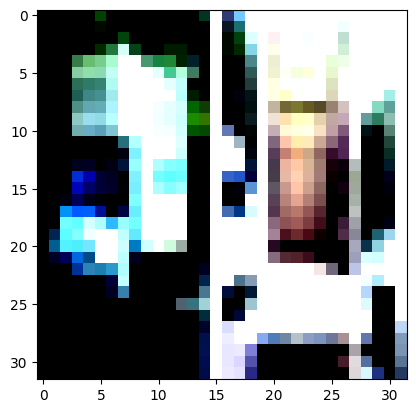

In [14]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [15]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [16]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [17]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [18]:
class Trainer:
    def __init__(self, config, model, transform=None):
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = model.to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.setup_dataloaders()

        # history for plots
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': []
        }

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(
            list(range(len(train_dataset_full))),
            test_size=self.config['test_size'],
            random_state=42,
            shuffle=True
        )
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self, verbose=True):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            if verbose:
                print(f"Epoch {epoch + 1} / {self.config['num_epochs']} | "
                      f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
                      f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}%")

        test_loss, test_acc = self.test_step()
        if verbose:
            print(f"Test loss {test_loss:.4f}, test acc {test_acc:.2f}%")

        return test_loss, test_acc

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader, desc='train', leave=False):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader, desc='val', leave=False):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader, desc='test', leave=False):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

In [19]:
cnn_trainer = Trainer(config, model=BasicCNN(), transform=transform)

In [20]:
cnn_test_loss, cnn_test_acc = cnn_trainer.run()

Epoch 1 / 10 | train_loss=1.6301 train_acc=40.34% | val_loss=1.3794 val_acc=50.35%


Epoch 2 / 10 | train_loss=1.3534 train_acc=51.17% | val_loss=1.2959 val_acc=53.76%


Epoch 3 / 10 | train_loss=1.2851 train_acc=53.79% | val_loss=1.2510 val_acc=55.76%


Epoch 4 / 10 | train_loss=1.2366 train_acc=55.99% | val_loss=1.2536 val_acc=55.13%


Epoch 5 / 10 | train_loss=1.2038 train_acc=57.03% | val_loss=1.2634 val_acc=55.51%


...

Epoch 7 / 10 | train_loss=1.0067 train_acc=64.08% | val_loss=1.1296 val_acc=60.54%


Epoch 8 / 10 | train_loss=0.9873 train_acc=64.77% | val_loss=1.1266 val_acc=60.19%


Epoch 9 / 10 | train_loss=0.9700 train_acc=65.34% | val_loss=1.1103 val_acc=60.70%


Epoch 10 / 10 | train_loss=0.9564 train_acc=65.70% | val_loss=1.1113 val_acc=60.87%


Test loss 1.1366, test acc 60.29%


# ResNet-18

Ниже — минимальная реализация ResNet-18 (адаптированная под CIFAR10: вход 32×32, поэтому первый conv без maxpool). Сравним её с простой CNN по графикам loss и accuracy.

In [21]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10):
        super().__init__()
        self.in_channels = 64

        # CIFAR10: 32x32, поэтому без maxpool
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        strides = [stride] + [1] * (blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, stride=s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def resnet18(num_classes=10):
    return ResNet(BasicBlock, layers=[2, 2, 2, 2], num_classes=num_classes)

In [22]:
resnet_trainer = Trainer(config, model=resnet18(num_classes=10), transform=transform)
resnet_test_loss, resnet_test_acc = resnet_trainer.run()

print('CNN test acc:', cnn_test_acc)
print('ResNet18 test acc:', resnet_test_acc)

Epoch 1 / 10 | train_loss=1.7710 train_acc=35.39% | val_loss=1.5383 val_acc=42.52%


Epoch 2 / 10 | train_loss=1.2730 train_acc=53.71% | val_loss=1.1514 val_acc=58.71%


Epoch 3 / 10 | train_loss=0.9792 train_acc=64.78% | val_loss=0.8812 val_acc=68.42%


Epoch 4 / 10 | train_loss=0.7794 train_acc=72.47% | val_loss=0.7342 val_acc=73.81%


KeyboardInterrupt: 

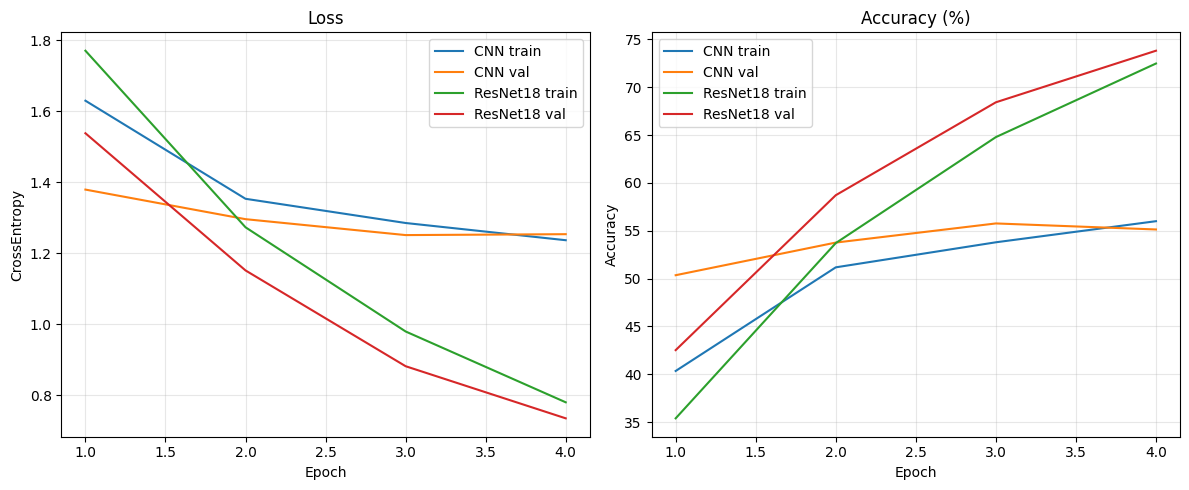

In [23]:
def plot_history(cnn_hist, resnet_hist):
    n = min(len(cnn_hist['train_loss']), len(resnet_hist['train_loss']))
    epochs = range(1, n + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, cnn_hist['train_loss'][:n], label='CNN train')
    plt.plot(epochs, cnn_hist['val_loss'][:n], label='CNN val')
    plt.plot(epochs, resnet_hist['train_loss'][:n], label='ResNet18 train')
    plt.plot(epochs, resnet_hist['val_loss'][:n], label='ResNet18 val')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('CrossEntropy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, cnn_hist['train_acc'][:n], label='CNN train')
    plt.plot(epochs, cnn_hist['val_acc'][:n], label='CNN val')
    plt.plot(epochs, resnet_hist['train_acc'][:n], label='ResNet18 train')
    plt.plot(epochs, resnet_hist['val_acc'][:n], label='ResNet18 val')
    plt.title('Accuracy (%)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(cnn_trainer.history, resnet_trainer.history)

In [ ]:
## Черновик (не используется)

Ниже была заготовка для ResNet18 с `...` — она **не используется** (рабочая реализация выше в `resnet18(...)`).
Оставлено только как черновик, **ячейку не запускать**.

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$